# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'
df = pd.read_csv(url)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection: 
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response:

**Who cares about this data**

The revenue manager is the obvious one. They set the nightly rate and decide how many rooms go to each channel, so they need to know which bookings are actually going to show up.

Operations cares for a different reason. They schedule housekeeping and front desk staff off expected occupancy. If a booking cancels two days out, the staff is already on the schedule and the food is already ordered. That money is gone.

Marketing is spending to acquire these bookings. If one channel is cheap per booking but half of them cancel, it isn't cheap.

Finance is forecasting revenue off a pipeline where a quarter of it isn't real.

**The problem**

About one in four bookings gets canceled here. That makes forward occupancy pretty useless for pricing or staffing, because you don't know how much of it is real.

So the question is: what can you see at the moment someone books that tells you whether they'll actually show up? It has to be knowable at booking time. Something recorded at check-out doesn't help you make a decision six months earlier.

## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:
# Structure and size
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   str    
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   str    
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            9404 non-null

In [3]:
# Numeric summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,9404.0,0.248299,0.432049,0.00,0.0,0.00,0.0,1.0
lead_time,9404.0,79.326244,87.584146,0.00,8.0,48.00,118.0,737.0
arrival_date_year,9404.0,2015.156104,0.443661,2015.00,2015.0,2015.00,2015.0,2017.0
arrival_date_week_number,9404.0,37.026584,11.083421,1.00,31.0,38.00,45.0,53.0
arrival_date_day_of_month,9404.0,15.515313,9.025545,1.00,7.0,16.00,23.0,31.0
stays_in_weekend_nights,9404.0,1.155040,1.124304,0.00,0.0,1.00,2.0,13.0
stays_in_week_nights,9404.0,3.078690,2.379227,0.00,1.0,3.00,5.0,33.0
adults,9404.0,1.864738,1.198565,0.00,2.0,2.00,2.0,55.0
children,9404.0,0.095279,0.393858,0.00,0.0,0.00,0.0,10.0
babies,9404.0,0.015419,0.125781,0.00,0.0,0.00,0.0,2.0


In [4]:
# Missing values and duplicates
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0])
print(f"\nPercent missing: company {missing['company']/len(df):.1%}, "
      f"agent {missing['agent']/len(df):.1%}, country {missing['country']/len(df):.1%}")
print(f"\nFully duplicated rows: {df.duplicated().sum():,} ({df.duplicated().mean():.1%} of the file)")

Columns with missing values:
country     266
agent      2335
company    8393
dtype: int64

Percent missing: company 89.2%, agent 24.8%, country 2.8%

Fully duplicated rows: 1,674 (17.8% of the file)


In [5]:
# Values that should not be possible
print(f"Bookings with ADR at or below zero: {(df['adr'] <= 0).sum()}")
print(f"Bookings with zero adults: {(df['adults'] == 0).sum()}")
print(f"\nHotel types present in the data: {df['hotel'].unique()}")

Bookings with ADR at or below zero: 230
Bookings with zero adults: 5

Hotel types present in the data: <StringArray>
['Resort Hotel']
Length: 1, dtype: str


### Reflection:
1. Name at least one structure issue you've found.
2. How can you fix this structural issue?

### ✍️ Your Response:

**The dataset isn't what the docs say it is.** The dictionary says there are two hotel types, City and Resort, and one of the listed use cases is comparing them. But the `hotel` column only has Resort Hotel in it. All 9,404 rows. So that comparison just can't be done with this file. Fix is to check the source before building anything around it, and drop the column since one value tells you nothing.

**1,674 rows are exact duplicates.** That's 17.8 percent of the file, which is too big to shrug at. Every count is inflated and every average is pulled toward whatever those repeated bookings look like. I wouldn't just drop them though. Two people could genuinely book the same thing the same day. I'd check whether they clump up on specific dates or channels first, because that would point to something breaking in the data pipeline rather than coincidence.

**`company` is empty on 89 percent of rows, `agent` on 25 percent.** These probably aren't really missing. A blank company almost certainly means the booking wasn't corporate. So the fix is to turn the blank into an actual category like "None" instead of imputing something. Filling in a company ID would be inventing a business relationship that doesn't exist.

**Some numbers are impossible.** 230 bookings have an ADR at or below zero, with the minimum at -6.38. Five bookings have zero adults. You can't sell a room for negative money and nobody stays in a room with no people in it. These are probably comped rooms or refund adjustments landing in the wrong field. They need to be flagged and pulled out of any pricing math, not averaged in.

**`reservation_status_date` came in as text.** Easy one. Convert it with `pd.to_datetime()` so it's usable.

## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

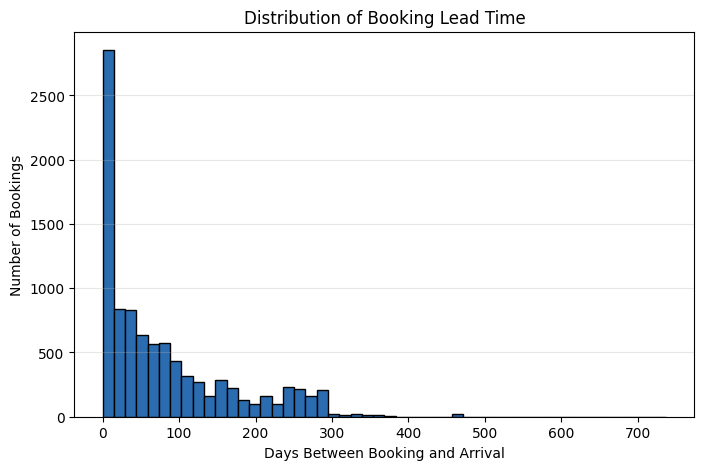

count    9404.0
mean       79.3
std        87.6
min         0.0
25%         8.0
50%        48.0
75%       118.0
max       737.0
Name: lead_time, dtype: float64


In [6]:
# Variable 1: lead time
plt.figure(figsize=(8, 5))
plt.hist(df['lead_time'], bins=50, color='#2b6cb0', edgecolor='black')
plt.title("Distribution of Booking Lead Time")
plt.xlabel("Days Between Booking and Arrival")
plt.ylabel("Number of Bookings")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(df['lead_time'].describe().round(1))

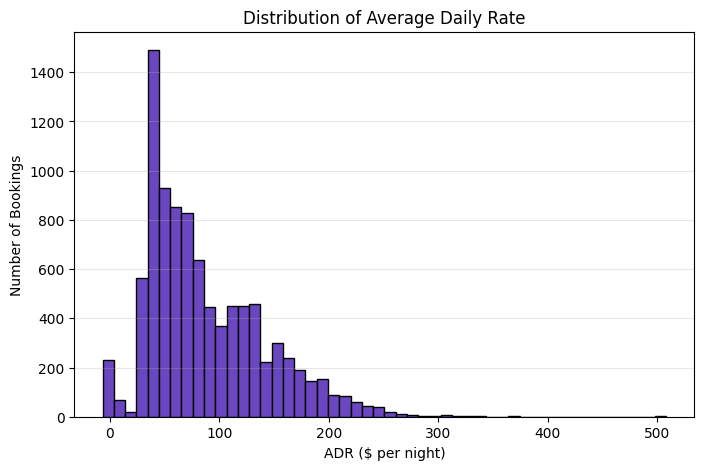

count    9404.00
mean       86.84
std        53.76
min        -6.38
25%        45.00
50%        71.55
75%       120.60
max       508.00
Name: adr, dtype: float64


In [7]:
# Variable 2: average daily rate
plt.figure(figsize=(8, 5))
plt.hist(df['adr'], bins=50, color='#6b46c1', edgecolor='black')
plt.title("Distribution of Average Daily Rate")
plt.xlabel("ADR ($ per night)")
plt.ylabel("Number of Bookings")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(df['adr'].describe().round(2))

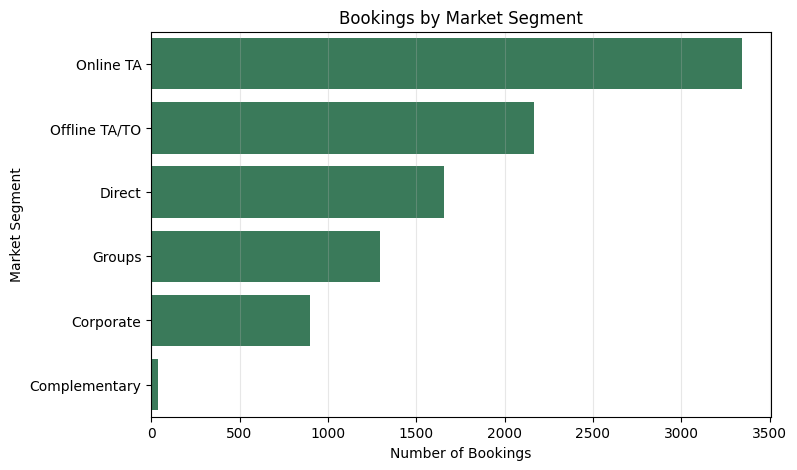

market_segment
Online TA        3341
Offline TA/TO    2169
Direct           1658
Groups           1296
Corporate         899
Complementary      41
Name: count, dtype: int64


In [8]:
# Variable 3: booking channel mix
seg_counts = df['market_segment'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=seg_counts.values, y=seg_counts.index, color='#2f855a')
plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")
plt.grid(axis='x', alpha=0.3)
plt.show()

print(seg_counts)

### ✍️ Your Response:

**Variable 1 - Lead time.** Really skewed to the right. Median is 48 days but the mean is 79, and somebody booked 737 days out, which is over two years. Meanwhile a quarter of bookings happen within 8 days of arrival.

What that says is this property is serving two pretty different customers. There's a last-minute crowd and there's a planning-way-ahead crowd. They don't behave the same, and section 5 shows they don't cancel at the same rate either.

**Variable 2 - Average daily rate.** Median 71.55, mean 86.84, so again skewed right with some expensive rooms up at 508 a night pulling the average.

The part that actually matters is at the bottom. The minimum is -6.38 and there are 230 bookings at or below zero. Negative revenue isn't a rate. It's a refund or a comped room that got logged in the wrong place. Until somebody separates those out, every average rate the revenue manager looks at is a little too low.

**Variable 3 - Market segment.** Online travel agencies are the biggest at 3,341, then Offline TA/TO at 2,169, Direct at 1,658, Groups at 1,296.

That's a lot of volume coming through third parties, and third parties take a commission that direct bookings don't. So more than a third of the business is arriving on the most expensive path. It gets worse when you see in section 5 that those channels also cancel more.

## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

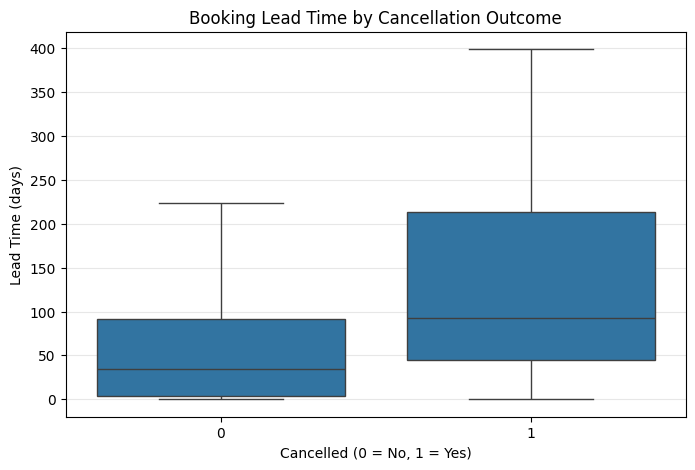

             median   mean  count
is_canceled                      
0              34.0   63.9   7069
1              93.0  126.1   2335


In [9]:
# Relationship 1: lead time vs cancellation
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=df, showfliers=False)
plt.title("Booking Lead Time by Cancellation Outcome")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (days)")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(df.groupby('is_canceled')['lead_time'].agg(['median', 'mean', 'count']).round(1))

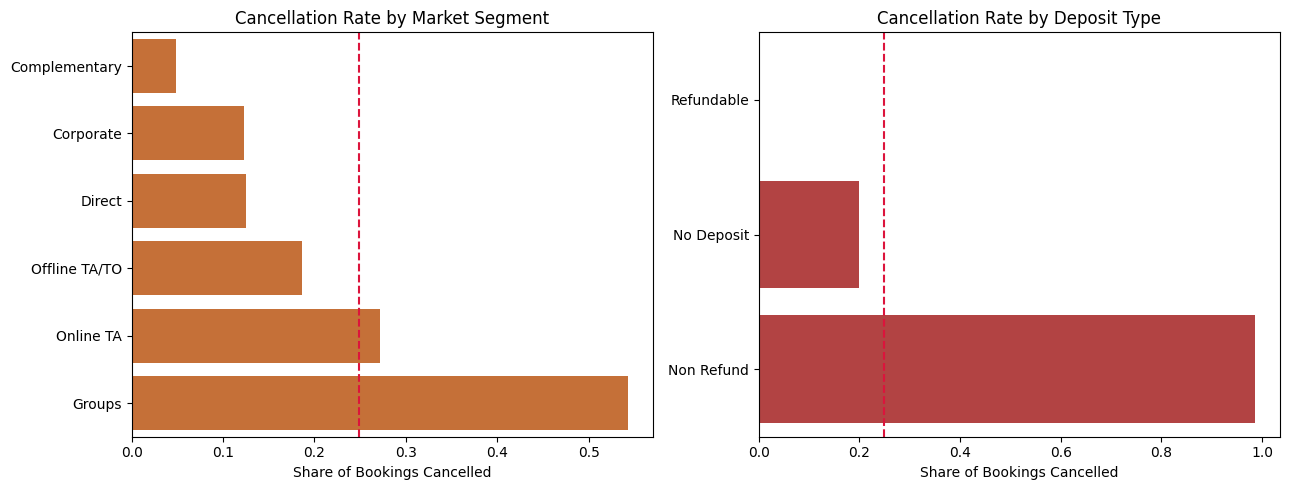

                 mean  count
market_segment              
Complementary   0.049     41
Corporate       0.123    899
Direct          0.125   1658
Groups          0.543   1296
Offline TA/TO   0.186   2169
Online TA       0.271   3341

               mean  count
deposit_type              
No Deposit    0.199   8816
Non Refund    0.986    585
Refundable    0.000      3


In [10]:
# Relationship 2: cancellation rate by market segment and deposit type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg = df.groupby('market_segment')['is_canceled'].mean().sort_values()
sns.barplot(x=seg.values, y=seg.index, color='#dd6b20', ax=axes[0])
axes[0].axvline(df['is_canceled'].mean(), color='crimson', linestyle='--')
axes[0].set_title("Cancellation Rate by Market Segment")
axes[0].set_xlabel("Share of Bookings Cancelled")
axes[0].set_ylabel("")

dep = df.groupby('deposit_type')['is_canceled'].mean().sort_values()
sns.barplot(x=dep.values, y=dep.index, color='#c53030', ax=axes[1])
axes[1].axvline(df['is_canceled'].mean(), color='crimson', linestyle='--')
axes[1].set_title("Cancellation Rate by Deposit Type")
axes[1].set_xlabel("Share of Bookings Cancelled")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(df.groupby('market_segment')['is_canceled'].agg(['mean', 'count']).round(3))
print()
print(df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']).round(3))

### ✍️ Your Response:

**Relationship 1 - Lead time vs cancellation.** Bookings that cancel have a median lead time of 93 days. Bookings that don't cancel: 34 days. Means are 126 and 64. So the further out somebody books, the less likely they are to actually come.

Which makes sense. Plans made six months ahead have a lot more time to fall apart than plans made next week. But the size of the gap is what makes it useful, close to three to one.

The best part is that lead time is sitting right there the second a booking comes in. No new data collection, no waiting. If you're building an overbooking model, this is the cheapest input you're going to find.

**Relationship 2 - Channel and deposit type.** Two things here, and the second one is strange.

Market segment splits hard against the 24.8 percent baseline. Groups cancel 54.3 percent of the time, more than double. Corporate is 12.3 percent and Direct is 12.5 percent. Online TA is 27.1 percent.

So the channel bringing the most volume is also less reliable than average, and the two cheapest channels are the two most dependable. That lines up nicely for marketing.

Now the weird one. Non-refundable bookings cancel 98.6 percent of the time. No Deposit bookings cancel 19.9 percent.

Read that straight and it says requiring a deposit makes people cancel, which is backwards and would be a terrible thing to act on. What's more likely is that the property is already spotting risky bookings and putting non-refundable terms on those specific ones. So the deposit is following the risk, not causing it. It's also possible guests who eat a non-refundable deposit just never formally cancel and get coded differently.

Either way you can't treat this as a lever until somebody explains the policy behind it. If you took it at face value you'd drop deposits exactly where they're doing their job.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection: 
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response:

**1. The insight I picked.** Bookings made far ahead cancel about three times as often as bookings made close in. Median 93 days for cancellations, 34 days for stays that happen.

**2. What kind of complexity.** Mostly **variability**. The booking process isn't steady, and the same booking is worth very different amounts depending on when it came in and where it came from. And it stacks. Lead time interacts with market segment, which interacts with deposit type, so any one booking's risk depends on a few things at once instead of one clean variable.

There's some **variety** in here too, just in the data itself. The useful signal is scattered across categorical fields like `market_segment` and `deposit_type`, numbers like `lead_time` and `adr`, and history like `previous_cancellations`. All of that needs different handling before you can put it together.

**3. What analytics would help.** Three stages, and jumping to the end is how people get this wrong.

Descriptive comes first. What's the baseline, 24.8 percent, and how does it move by segment. That's what the charts above do, and it's already enough for operations to staff differently.

Diagnostic matters a lot here, specifically because of the deposit thing. A model that saw 98.6 percent and acted on it would recommend the wrong policy. Figuring out why that relationship runs backwards means digging into how the business actually works, and no algorithm is going to do that on its own.

Predictive is where this eventually goes. Score every incoming booking for cancellation risk so overbooking gets set per date instead of one flat number. All the variables needed are available at booking time, so it's doable.

I'd hold off on prescriptive. Automatically moving prices or deposit terms based on a risk score gets into fairness and guest experience territory, and people should make that call, not a model. At least not until the diagnostic work is done.

## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection: 
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response:

**1. What stood out.**

Cancellations aren't random. They pile up in groups you can spot at booking time. Long lead times cancel about three times as often as short ones. Groups cancel 54.3 percent against a 24.8 percent baseline. Repeat guests cancel 11.5 percent versus 26.0 percent for new guests, less than half. And bookings with zero special requests cancel 29.1 percent while bookings with four cancel 14.6 percent, which suggests that any small bit of engagement with the reservation means the person actually intends to show up.

Sitting under all of it is a data problem big enough that it qualifies everything above. 17.8 percent duplicate rows, and only one of the two hotel types the documentation promised.

**2. How that connects to what people need.**

Revenue manager gets to overbook by date instead of applying one number across the calendar. Protects occupancy on the risky dates without paying walk costs on the safe ones.

Operations can discount forward occupancy by expected cancellation rate, which turns staffing from a guess into an estimate.

Marketing gets the clearest read. Direct and Corporate cost less in commission and cancel at half the rate of Groups. So the real cost per completed stay is way further apart than the commission rate alone makes it look.

**3. What I'd recommend.**

Fix the data first. Deal with the 1,674 duplicates and find out whether the missing hotel type is a sampling thing or a real gap. Everything here has an asterisk on it until that's settled.

Then build a risk score at booking time off lead time, market segment, customer type, and repeat guest status. Use it to set overbooking per date.

Move acquisition spend toward Direct and Corporate, and judge channels on cost per completed stay instead of cost per booking.

And leave deposit policy alone until somebody explains the 98.6 percent. That number almost certainly reflects triage that's already happening, and acting on the surface reading would strip protection off exactly the bookings that need it.

**4. How this ties to my customized learning outcome.**

> 🔧 **You write this one.** I don't know what outcome you set in Canvas. Pull it up and connect it to something specific from this notebook. If it's about explaining analysis to people who aren't analysts, the deposit finding is your example, since the honest answer meant explaining why the obvious read was wrong. If it's about data quality or making calls under uncertainty, use the duplicate rows and the missing hotel type instead.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [11]:
# !jupyter nbconvert --to html "assignment_05_eda.ipynb" 